In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


/data/ll2531/venv/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
with open("processed_data_pkl/imputed_training_data.pkl", "rb") as f:
    traffic_dic = pickle.load(f)

with open("processed_data_pkl/weather_global_2014_2025.pkl", "rb") as f:
    weather = pickle.load(f)

air_qual = pd.read_csv("online_data/air_qual/air_qual.csv")

air_qual.drop(columns=["aerosol_optical_depth ()", "dust (μg/m³)"], errors="ignore", inplace=True)
air_qual.dropna(inplace=True)
air_qual.reset_index(inplace=True, drop=True)

air_qual["time"] = pd.to_datetime(air_qual["time"], errors="coerce")
weather["timestamp"] = pd.to_datetime(weather["timestamp"], errors="coerce")

weather = weather[weather["timestamp"].isin(air_qual["time"])]
weather.reset_index(inplace=True, drop=True)

dataset = pd.merge(weather, air_qual, left_on="timestamp", right_on="time", how="inner")


In [3]:
dataset["hour_sin"] = dataset["timestamp"].apply(lambda x: np.sin(2 * np.pi * x.hour / 24.0))
dataset["hour_cos"] = dataset["timestamp"].apply(lambda x: np.cos(2 * np.pi * x.hour / 24.0))

In [4]:
FEATURE_COLS = ["pm2_5 (μg/m³)", "hour_sin", "hour_cos"]
TARGET_COL = "pm2_5 (μg/m³)"
N_FEATURES = len(FEATURE_COLS)
TARGET_SCALER_IDX = FEATURE_COLS.index(TARGET_COL)


df = dataset[FEATURE_COLS + ["timestamp"]].copy()
df.set_index("timestamp", inplace=True)
df = df.sort_index().asfreq("h") 

INPUT_WINDOW = 24 *3
OUTPUT_WINDOW = 24
BATCH_SIZE = 64

train_raw = df.loc[:"2024-12-31 23:00:00", FEATURE_COLS].copy()
test_raw = df.loc["2025-01-01 00:00:00":"2025-01-31 23:00:00", FEATURE_COLS].copy()

scaler = MinMaxScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train_raw), columns=FEATURE_COLS, index=train_raw.index)
test_scaled = pd.DataFrame(scaler.transform(test_raw), columns=FEATURE_COLS, index=test_raw.index)


def create_clock_anchored_sequences(df_scaled, feature_cols, target_col, input_w, output_w):
    X, Y = [], []
    feature_matrix = df_scaled[feature_cols].values
    target_vector = df_scaled[target_col].values
    
    for i in range(len(df_scaled) - input_w - output_w + 1):
        X.append(feature_matrix[i : i + input_w, :])
        Y.append(target_vector[i + input_w : i + input_w + output_w])
        
    return np.array(X), np.array(Y)

X_train, y_train = create_clock_anchored_sequences(train_scaled, FEATURE_COLS, TARGET_COL, INPUT_WINDOW, OUTPUT_WINDOW)
X_test, y_test = create_clock_anchored_sequences(test_scaled, FEATURE_COLS, TARGET_COL, INPUT_WINDOW, OUTPUT_WINDOW)

In [5]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [6]:
class LSTM_model(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=48, num_layers=2, output_dim=24):
        super(LSTM_model, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True, 
            dropout=0.2
        )
        
        self.fc_block = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]
        out = self.fc_block(last_hidden)
        return out
    
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTM_model(input_dim=N_FEATURES, hidden_dim=64, num_layers=2, output_dim=OUTPUT_WINDOW).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

In [7]:
hist_train = []
hist_val = []
epoches = 60

for epoch in range(epoches):
    model.train()
    epoch_train_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(DEVICE, non_blocking=True)
        batch_y = batch_y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_train_loss += loss.item() * batch_x.size(0)

    total_train_loss = epoch_train_loss / len(train_loader.dataset)
    hist_train.append(total_train_loss)


    model.eval()
    epoch_val_loss = 0.0
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(DEVICE, non_blocking=True)
            batch_y = batch_y.to(DEVICE, non_blocking=True)
            
            val_predictions = model(batch_x)
            val_loss = criterion(val_predictions, batch_y)
            
            epoch_val_loss += val_loss.item() * batch_x.size(0)
            
    total_val_loss = epoch_val_loss / len(test_loader.dataset)
    hist_val.append(total_val_loss)

    print(f"Epoch {epoch+1:02d}/{epoches} | {total_train_loss:<18.6f} | {total_val_loss:<18.6f}")

Epoch 01/60 | 0.004046           | 0.003303          
Epoch 02/60 | 0.003272           | 0.003597          
Epoch 03/60 | 0.003190           | 0.003175          
Epoch 04/60 | 0.003158           | 0.003125          
Epoch 05/60 | 0.003150           | 0.003103          
Epoch 06/60 | 0.003125           | 0.003128          
Epoch 07/60 | 0.003108           | 0.003115          
Epoch 08/60 | 0.003105           | 0.003112          
Epoch 09/60 | 0.003094           | 0.003141          
Epoch 10/60 | 0.003075           | 0.003088          
Epoch 11/60 | 0.003091           | 0.003205          
Epoch 12/60 | 0.003085           | 0.003028          
Epoch 13/60 | 0.003079           | 0.003056          
Epoch 14/60 | 0.003085           | 0.003024          
Epoch 15/60 | 0.003081           | 0.003072          
Epoch 16/60 | 0.003074           | 0.002982          
Epoch 17/60 | 0.003064           | 0.003011          
Epoch 18/60 | 0.003059           | 0.003081          
Epoch 19/60 | 0.003074      

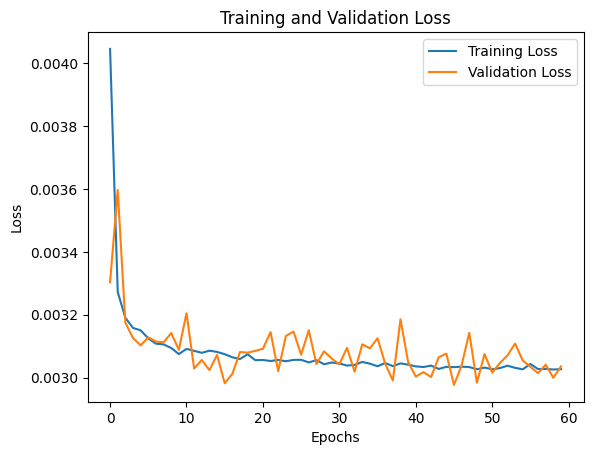

In [8]:
plt.plot(hist_train, label='Training Loss')
plt.plot(hist_val, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

In [9]:
def inverse_transform_target(scaled_data, scaler, target_idx, n_features):
    flat_data = scaled_data.flatten()
    dummy = np.zeros((len(flat_data), n_features))
    dummy[:, target_idx] = flat_data
    unscaled_dummy = scaler.inverse_transform(dummy)
    return unscaled_dummy[:, target_idx].reshape(scaled_data.shape)

In [10]:
model.eval()
with torch.no_grad():
    seed_data = train_scaled[FEATURE_COLS].values[-INPUT_WINDOW:]
    seed_tensor = torch.tensor(seed_data, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    scaled_prediction = model(seed_tensor).cpu().numpy().flatten()

true_predictions = inverse_transform_target(scaled_prediction, scaler, TARGET_SCALER_IDX, N_FEATURES)
actual_values = inverse_transform_target(y_test[0], scaler, TARGET_SCALER_IDX, N_FEATURES)
forecast_timestamps = df.loc["2025-01-01 00:00:00":"2025-01-01 23:00:00"].index

In [15]:
model.eval()
all_predictions = []
all_ground_truth = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(DEVICE)
        
        preds = model(batch_x).cpu().numpy()
        actuals = batch_y.numpy()
        
        all_predictions.append(preds)
        all_ground_truth.append(actuals)

all_predictions = np.vstack(all_predictions)
all_ground_truth = np.vstack(all_ground_truth)

true_predictions_all = inverse_transform_target(all_predictions, scaler, TARGET_SCALER_IDX, N_FEATURES)
true_ground_truth_all = inverse_transform_target(all_ground_truth, scaler, TARGET_SCALER_IDX, N_FEATURES)

global_mae = mean_absolute_error(true_ground_truth_all.flatten(), true_predictions_all.flatten())
global_rmse = np.sqrt(mean_squared_error(true_ground_truth_all.flatten(), true_predictions_all.flatten()))
global_r2 = r2_score(true_ground_truth_all.flatten(), true_predictions_all.flatten())

ground_truth_mean = np.mean(true_ground_truth_all)
mae_percentage = (global_mae / ground_truth_mean)
rmse_percentage = (global_rmse / ground_truth_mean)

print(f"Global R² Score     : {global_r2:.4f}")
print(f"Global MAE          : {global_mae:.4f} μg/m³")
print(f"Global RMSE         : {global_rmse:.4f} μg/m³")
print(f"MAE% (Normalized)   : {mae_percentage:.2f}")
print(f"RMSE% (Normalized)  : {rmse_percentage:.2f}")


Global R² Score     : 0.5903
Global MAE          : 3.0762 μg/m³
Global RMSE         : 4.1265 μg/m³
MAE% (Normalized)   : 0.33
RMSE% (Normalized)  : 0.44


In [12]:
import plotly.graph_objects as go

model.eval()

sample_indices = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600]
num_samples = len(sample_indices)

# Initialize the master canvas
fig = go.Figure()

buttons = []

for idx, sample_idx in enumerate(sample_indices):
    
    raw_x = X_test[sample_idx]
    raw_y = y_test[sample_idx]
    
    tensor_x = torch.tensor(raw_x, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        scaled_pred = model(tensor_x).cpu().numpy().flatten()
        
    true_pred = inverse_transform_target(scaled_pred, scaler, TARGET_SCALER_IDX, N_FEATURES)
    true_actual = inverse_transform_target(raw_y, scaler, TARGET_SCALER_IDX, N_FEATURES)
    
    start_timestamp_idx = INPUT_WINDOW + sample_idx
    window_timestamps = df.loc["2025-01-01 00:00:00":"2025-01-31 23:00:00"].index[
        start_timestamp_idx : start_timestamp_idx + OUTPUT_WINDOW
    ]
    time_labels = [str(t).split()[1][:5] for t in window_timestamps]
    date_str = str(window_timestamps[0]).split()[0]
    
    fig.add_trace(go.Scatter(
        x=time_labels, y=true_actual,
        mode='lines+markers',
        name=f'Actual PM2.5 ({date_str})',
        line=dict(color='seagreen', width=3),
        visible=(idx == 0)
    ))
    
    fig.add_trace(go.Scatter(
        x=time_labels, y=true_pred,
        mode='lines+markers',
        name=f'LSTM Forecast ({date_str})',
        line=dict(color='royalblue', width=2, dash='dash'),
        visible=(idx == 0)
    ))
    
    visibility_mask = [False] * (num_samples * 2)
    visibility_mask[idx * 2] = True
    visibility_mask[idx * 2 + 1] = True
    
    buttons.append(dict(
        label=f"Horizon: {date_str}",
        method="update",
        args=[
            {"visible": visibility_mask},
            {"title": f"<b>Multivariate LSTM Performance Horizon: {date_str}</b>"} 
        ]
    ))

initial_date_str = str(df.loc["2025-01-01 00:00:00":"2025-01-31 23:00:00"].index[INPUT_WINDOW]).split()[0]

fig.update_layout(
    title=dict(
        text=f'<b>Multivariate LSTM Performance Horizon: {initial_date_str}</b>',
        x=0.5,
        font=dict(size=16)
    ),
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.0,
            xanchor="left",
            y=1.15,
            yanchor="top"
        )
    ],
    xaxis=dict(title='Hour of Day (24h Forecast Horizon)', showgrid=True, gridcolor='lightgray'),
    yaxis=dict(title='PM2.5 Concentration (μg/m³)', showgrid=True, gridcolor='lightgray'),
    template='plotly_white',
    hovermode='x unified',
    height=550,
    width=900,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig.show()